# Bước 2 — Thống kê mô tả
**Input:** `data_sach.csv` (output từ Bước 1)  
**Output:** Bảng thống kê mô tả + biểu đồ phân phối → dùng thẳng trong bài báo

---
### Nội dung
1. Load data
2. Thống kê nhân khẩu học (bảng + biểu đồ)
3. Thống kê mô tả từng biến quan sát (Mean, SD, Min, Max)
4. Thống kê mô tả theo nhóm biến (construct-level)
5. Phân phối điểm từng nhóm (histogram)
6. Heatmap tương quan sơ bộ
7. Xuất bảng Word-ready

In [ ]:
!pip install openpyxl seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 130
print('Sẵn sàng!')

Sẵn sàng!


In [ ]:
# Upload data_sach.csv
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f'N = {len(df)} | Cột: {len(df.columns)}')

Saving data_sach (1).csv to data_sach (1).csv
N = 193 | Cột: 44


In [ ]:
# Định nghĩa nhóm biến
groups = {
    'EE':  [f'EE{i}'  for i in range(1,6)],
    'PE':  [f'PE{i}'  for i in range(1,6)],
    'SI':  [f'SI{i}'  for i in range(1,6)],
    'FC':  [f'FC{i}'  for i in range(1,6)],
    'RA':  [f'RA{i}'  for i in range(1,6)],
    'ANX': [f'ANX{i}' for i in range(1,6)],
    'BI':  [f'BI{i}'  for i in range(1,6)],
}
group_labels = {
    'EE':  'Effort Expectancy',
    'PE':  'Performance Expectancy',
    'SI':  'Social Influence',
    'FC':  'Facilitating Conditions',
    'RA':  'Responsible AI Awareness',
    'ANX': 'AI Anxiety',
    'BI':  'Behavioral Intention',
}
likert_cols = [c for cols in groups.values() for c in cols]
print('Định nghĩa nhóm biến xong!')

Định nghĩa nhóm biến xong!


---
## 1. Thống kê nhân khẩu học

In [ ]:
def freq_table(series, title):
    vc = series.value_counts()
    pct = (vc / len(series) * 100).round(1)
    tbl = pd.DataFrame({'Tần số': vc, 'Tỷ lệ (%)': pct})
    print(f'\n── {title} ──')
    print(tbl.to_string())
    return tbl

t_group = freq_table(df['group'],    'Nhóm đối tượng')
t_major = freq_table(df['major'],    'Ngành học')
t_usage = freq_table(df['ai_usage'], 'Mức độ dùng AI')


── Nhóm đối tượng ──
                                       Tần số  Tỷ lệ (%)
group                                                   
Sinh viên năm cuối (chưa tốt nghiệp)      144       74.6
Đã tốt nghiệp, đang đi làm dưới 2 năm      49       25.4

── Ngành học ──
                                         Tần số  Tỷ lệ (%)
major                                                     
Kỹ thuật / CNTT / Khoa học dữ liệu           62       32.1
Khoa học xã hội / Nhân văn / Ngôn ngữ        51       26.4
Kinh tế / Quản trị / Kế toán                 46       23.8
Ngành khác: ___________________________      34       17.6

── Mức độ dùng AI ──
                                          Tần số  Tỷ lệ (%)
ai_usage                                                   
Dùng thường xuyên (vài lần/tuần trở lên)     163       84.5
Đã thử 1–2 lần                                24       12.4
Chưa bao giờ                                   6        3.1


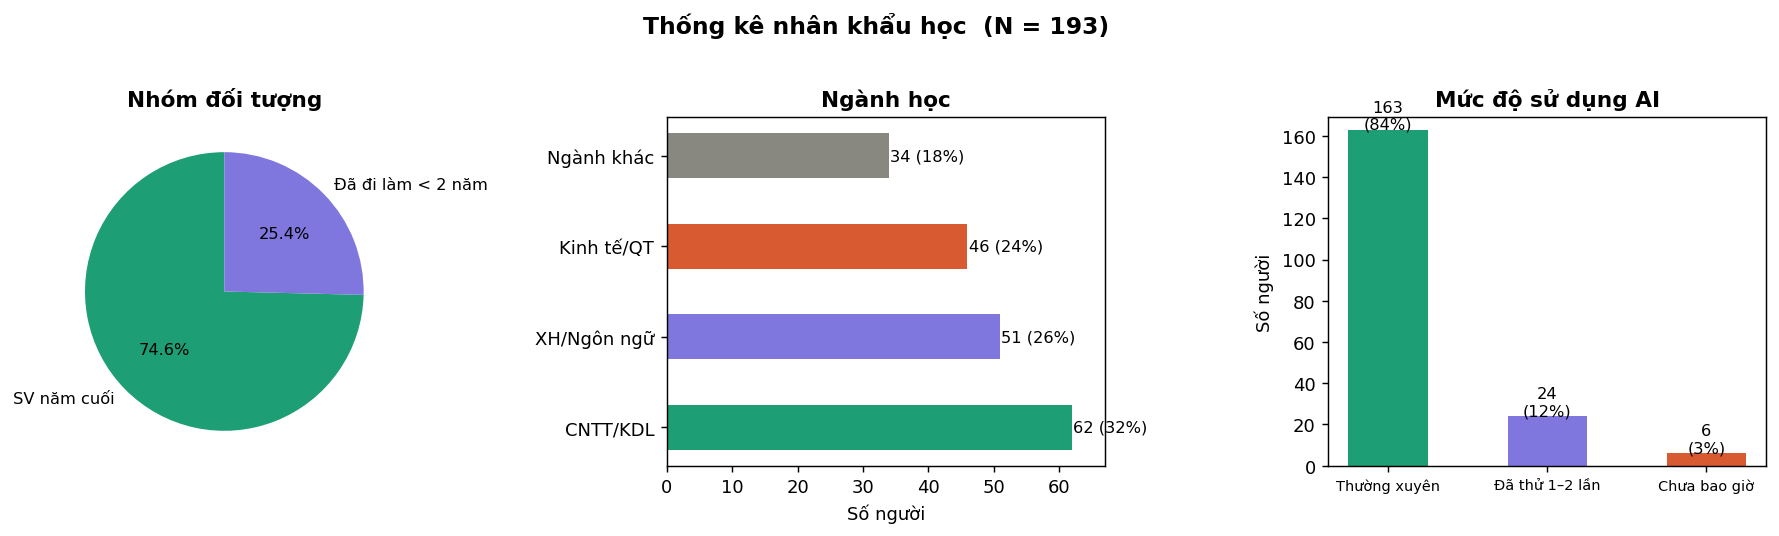

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'Thống kê nhân khẩu học  (N = {len(df)})', fontsize=13, fontweight='bold', y=1.02)

COLORS = ['#1D9E75','#7F77DD','#D85A30','#888780','#BA7517']

# Nhóm đối tượng — pie
g_data = df['group'].value_counts()
g_labels = ['SV năm cuối', 'Đã đi làm < 2 năm']
wedges, texts, autotexts = axes[0].pie(
    g_data.values, labels=g_labels[:len(g_data)],
    autopct='%1.1f%%', colors=COLORS[:len(g_data)],
    startangle=90, textprops={'fontsize': 9})
axes[0].set_title('Nhóm đối tượng', fontweight='bold')

# Ngành học — bar ngang
m_data = df['major'].value_counts()
m_short = {'Kỹ thuật / CNTT / Khoa học dữ liệu': 'CNTT/KDL',
           'Kinh tế / Quản trị / Kế toán': 'Kinh tế/QT',
           'Khoa học xã hội / Nhân văn / Ngôn ngữ': 'XH/Ngôn ngữ',
           'Ngành khác: ___________________________': 'Ngành khác'}
m_labels = [m_short.get(k, k[:12]) for k in m_data.index]
bars = axes[1].barh(m_labels, m_data.values, color=COLORS[:len(m_data)], height=0.5)
axes[1].set_xlabel('Số người')
axes[1].set_title('Ngành học', fontweight='bold')
for bar, v in zip(bars, m_data.values):
    axes[1].text(v + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{v} ({v/len(df)*100:.0f}%)', va='center', fontsize=9)
axes[1].set_xlim(0, m_data.max() + 5)

# Mức độ dùng AI — bar
u_data = df['ai_usage'].value_counts()
u_short = {'Dùng thường xuyên (vài lần/tuần trở lên)': 'Thường xuyên',
           'Đã thử 1–2 lần': 'Đã thử 1–2 lần',
           'Chưa bao giờ': 'Chưa bao giờ'}
u_labels = [u_short.get(k, k) for k in u_data.index]
bars2 = axes[2].bar(u_labels, u_data.values,
                    color=COLORS[:len(u_data)], width=0.5)
axes[2].set_ylabel('Số người')
axes[2].set_title('Mức độ sử dụng AI', fontweight='bold')
axes[2].tick_params(axis='x', labelsize=8)
for bar, v in zip(bars2, u_data.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 f'{v}\n({v/len(df)*100:.0f}%)', ha='center', fontsize=9)
axes[2].set_ylim(0, u_data.max() + 6)

plt.tight_layout()
plt.savefig('bieu_do_nhan_khau.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Thống kê mô tả từng biến quan sát

In [ ]:
# Bảng thống kê từng item — dùng trong phụ lục bài báo
rows = []
for g, cols in groups.items():
    for col in cols:
        s = df[col]
        rows.append({
            'Nhóm': g,
            'Biến': col,
            'N':    s.count(),
            'Mean': round(s.mean(), 3),
            'SD':   round(s.std(),  3),
            'Min':  int(s.min()),
            'Max':  int(s.max()),
            'Skewness': round(s.skew(), 3),
            'Kurtosis': round(s.kurt(), 3),
        })

df_desc = pd.DataFrame(rows)
pd.set_option('display.max_rows', 40)
print(df_desc.to_string(index=False))

Nhóm Biến   N  Mean    SD  Min  Max  Skewness  Kurtosis
  EE  EE1 193 3.606 1.177    1    5    -0.916     0.155
  EE  EE2 193 3.731 1.104    1    5    -1.256     1.045
  EE  EE3 193 3.482 1.151    1    5    -0.318    -0.423
  EE  EE4 193 3.373 1.157    1    5    -0.604    -0.402
  EE  EE5 193 3.715 1.176    1    5    -0.945     0.357
  PE  PE1 193 3.674 1.209    1    5    -0.977     0.196
  PE  PE2 193 3.518 1.225    1    5    -0.832    -0.279
  PE  PE3 193 3.451 1.233    1    5    -0.745    -0.335
  PE  PE4 193 3.855 1.141    1    5    -1.242     1.046
  PE  PE5 193 3.736 1.185    1    5    -1.202     0.737
  SI  SI1 193 3.497 1.036    1    5    -0.688     0.518
  SI  SI2 193 3.549 1.055    1    5    -0.762     0.496
  SI  SI3 193 3.337 1.111    1    5    -0.606    -0.102
  SI  SI4 193 3.368 1.068    1    5    -0.546     0.117
  SI  SI5 193 3.627 1.029    1    5    -0.709     0.437
  FC  FC1 193 3.653 1.237    1    5    -0.798    -0.120
  FC  FC2 193 3.212 1.066    1    5    -0.408   

---
## 3. Thống kê mô tả cấp nhóm (construct-level)

In [ ]:
# Tính composite score (mean của các item trong nhóm)
for g, cols in groups.items():
    df[f'{g}_score'] = df[cols].mean(axis=1)

score_cols = [f'{g}_score' for g in groups]

construct_rows = []
for g in groups:
    s = df[f'{g}_score']
    construct_rows.append({
        'Nhóm biến': f'{g} ({group_labels[g]})',
        'N items':   5,
        'Mean':      round(s.mean(), 3),
        'SD':        round(s.std(),  3),
        'Min':       round(s.min(),  2),
        'Max':       round(s.max(),  2),
        'Skewness':  round(s.skew(), 3),
    })

df_construct = pd.DataFrame(construct_rows)
print('=== THỐNG KÊ MÔ TẢ CẤP NHÓM ===')
print(df_construct.to_string(index=False))

=== THỐNG KÊ MÔ TẢ CẤP NHÓM ===
                    Nhóm biến  N items  Mean    SD  Min  Max  Skewness
       EE (Effort Expectancy)        5 3.581 0.862  1.0  5.0    -0.766
  PE (Performance Expectancy)        5 3.647 0.960  1.0  5.0    -0.893
        SI (Social Influence)        5 3.476 0.819  1.0  5.0    -0.602
 FC (Facilitating Conditions)        5 3.370 0.830  1.0  5.0    -0.488
RA (Responsible AI Awareness)        5 3.963 0.847  1.0  5.0    -0.857
             ANX (AI Anxiety)        5 3.728 0.789  1.0  5.0    -0.556
    BI (Behavioral Intention)        5 3.861 0.801  1.6  5.0    -0.516


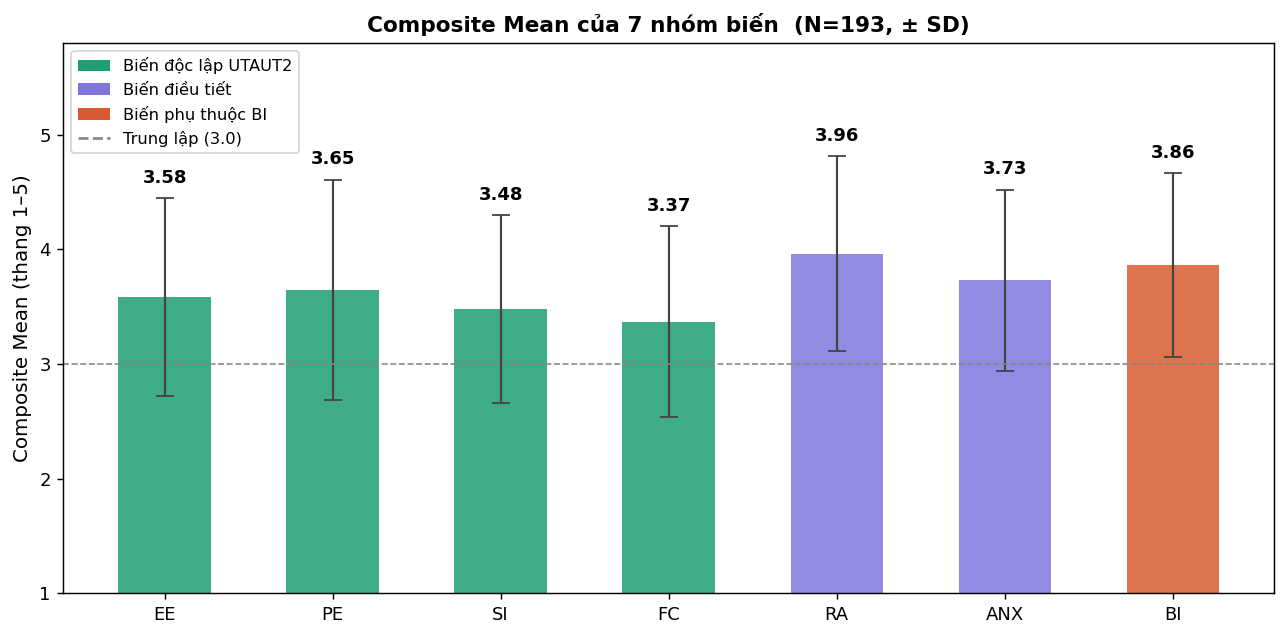

In [ ]:
# Biểu đồ mean construct + error bar SD
fig, ax = plt.subplots(figsize=(10, 5))

g_keys  = list(groups.keys())
means   = [df[f'{g}_score'].mean() for g in g_keys]
sds     = [df[f'{g}_score'].std()  for g in g_keys]
colors  = ['#1D9E75']*4 + ['#7F77DD']*2 + ['#D85A30']

bars = ax.bar(g_keys, means, yerr=sds, capsize=5,
              color=colors, alpha=0.85, width=0.55,
              error_kw={'linewidth': 1.2, 'ecolor': '#444441'})
ax.axhline(3, color='#888780', linestyle='--', linewidth=0.9, label='Điểm trung lập (3.0)')
ax.set_ylim(1, 5.8)
ax.set_ylabel('Composite Mean (thang 1–5)', fontsize=11)
ax.set_title(f'Composite Mean của 7 nhóm biến  (N={len(df)}, ± SD)', fontweight='bold', fontsize=12)

for bar, m, sd in zip(bars, means, sds):
    ax.text(bar.get_x() + bar.get_width()/2, m + sd + 0.1,
            f'{m:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor='#1D9E75', label='Biến độc lập UTAUT2'),
    Patch(facecolor='#7F77DD', label='Biến điều tiết'),
    Patch(facecolor='#D85A30', label='Biến phụ thuộc BI'),
]
ax.legend(handles=legend_els + [plt.Line2D([0],[0], color='#888780',
          linestyle='--', label='Trung lập (3.0)')],
          loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('bieu_do_mean_construct.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Phân phối điểm từng nhóm (histogram)

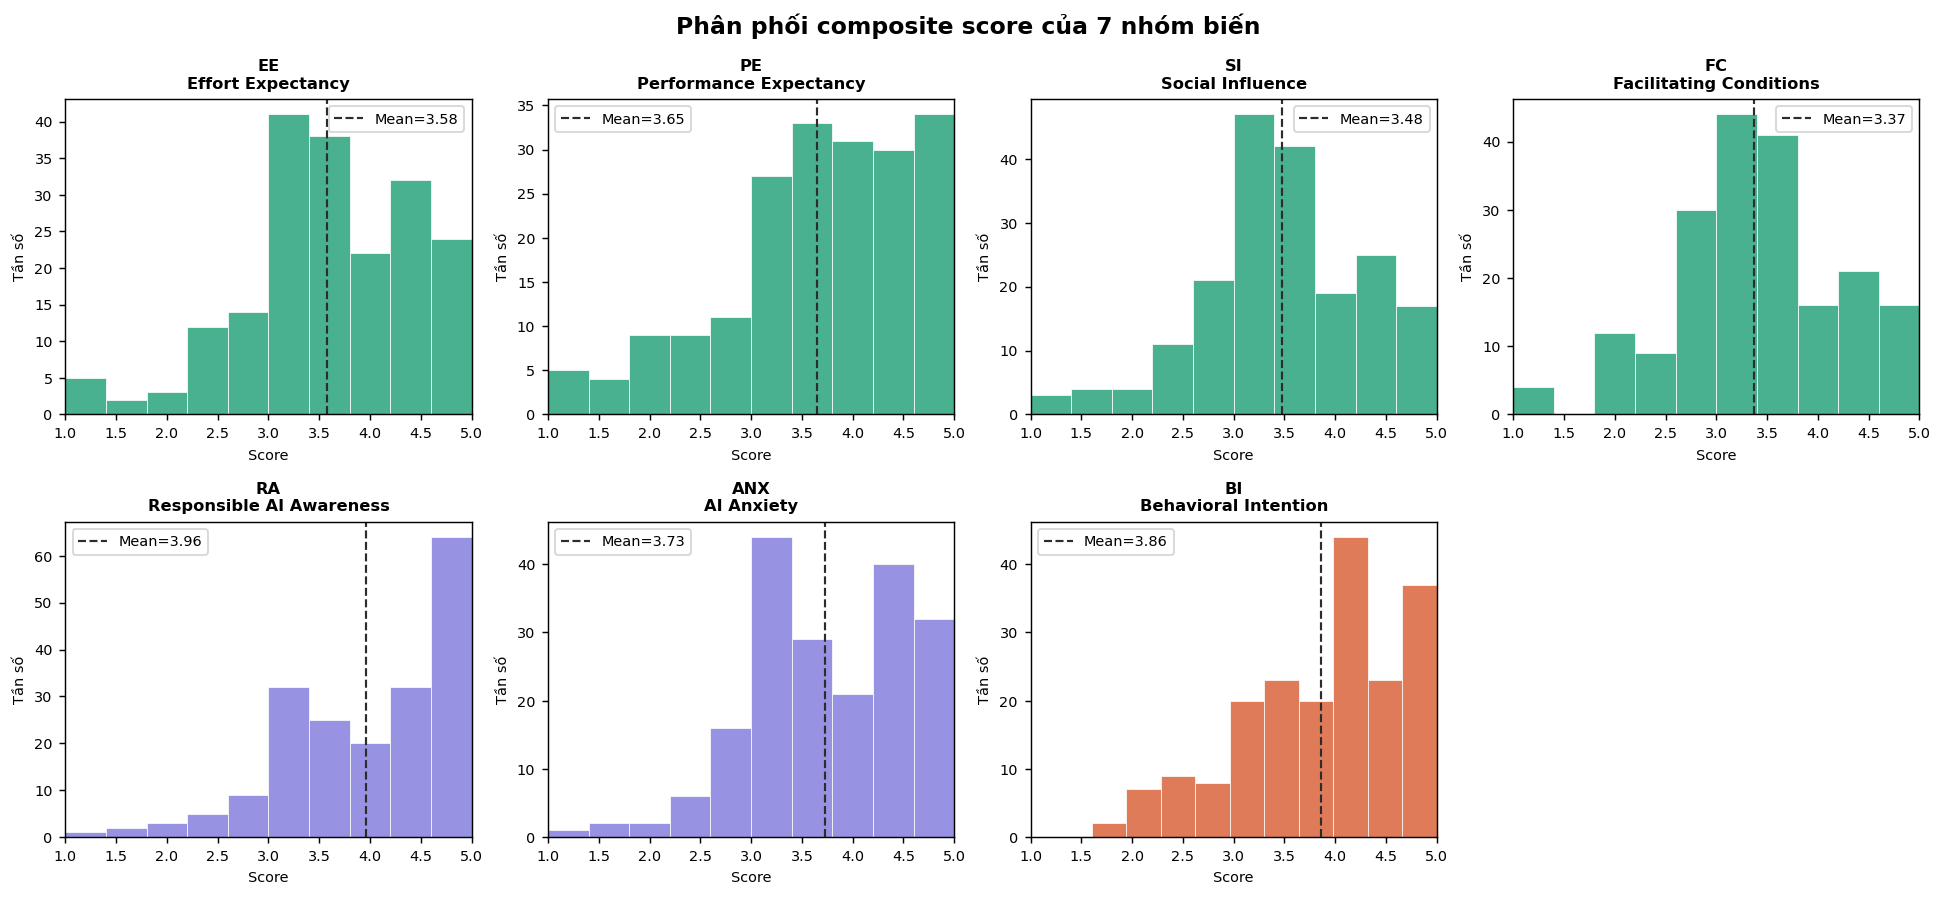

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
fig.suptitle('Phân phối composite score của 7 nhóm biến', fontsize=13, fontweight='bold')
axes = axes.flatten()

colors_map = {'EE':'#1D9E75','PE':'#1D9E75','SI':'#1D9E75','FC':'#1D9E75',
              'RA':'#7F77DD','ANX':'#7F77DD','BI':'#D85A30'}

for i, g in enumerate(groups):
    ax = axes[i]
    data = df[f'{g}_score']
    ax.hist(data, bins=10, color=colors_map[g], alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(data.mean(), color='#2C2C2A', linestyle='--', linewidth=1.2,
               label=f'Mean={data.mean():.2f}')
    ax.set_title(f'{g}\n{group_labels[g]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Score', fontsize=8)
    ax.set_ylabel('Tần số', fontsize=8)
    ax.set_xlim(1, 5)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

# Ẩn ô trống cuối
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('bieu_do_phan_phoi.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Heatmap tương quan sơ bộ giữa các nhóm

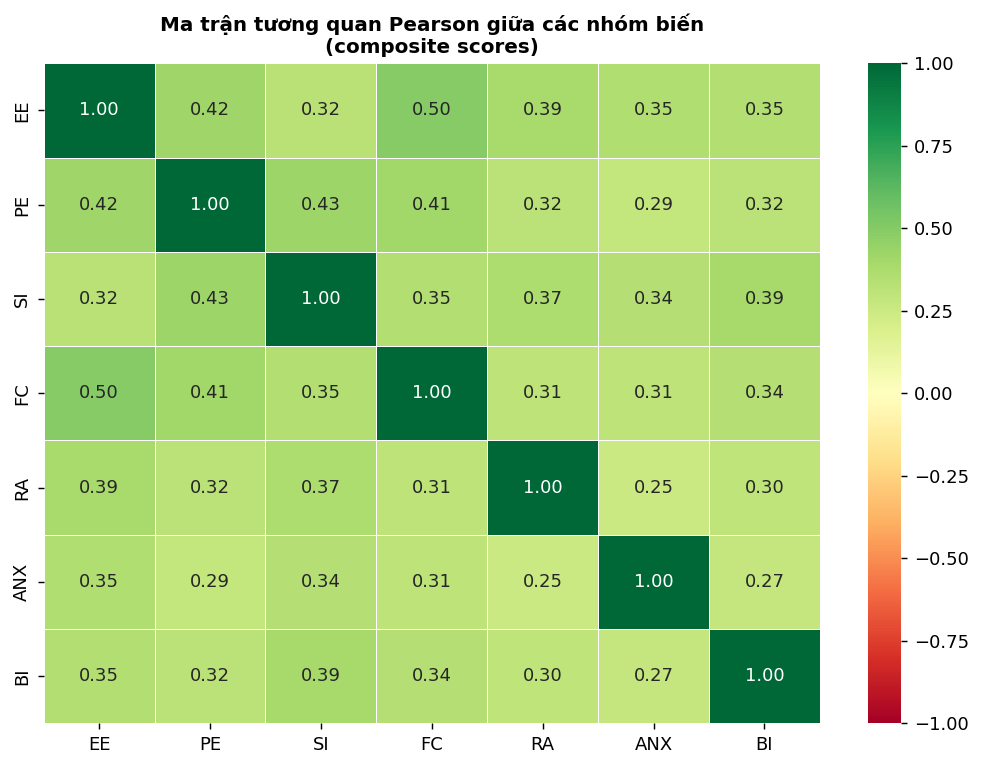


Giải thích nhanh:
r > 0.5 → tương quan khá mạnh (cần kiểm tra multicollinearity ở bước SEM)
r < 0.3 → tương quan yếu (có thể giả thuyết bị bác bỏ)


In [ ]:
corr_df = df[score_cols].copy()
corr_df.columns = list(groups.keys())
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10},
            ax=ax)
ax.set_title('Ma trận tương quan Pearson giữa các nhóm biến\n(composite scores)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('heatmap_tuong_quan.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nGiải thích nhanh:')
print('r > 0.5 → tương quan khá mạnh (cần kiểm tra multicollinearity ở bước SEM)')
print('r < 0.3 → tương quan yếu (có thể giả thuyết bị bác bỏ)')

---
## 6. Xuất bảng & file

In [ ]:
with pd.ExcelWriter('thong_ke_mo_ta.xlsx', engine='openpyxl') as writer:
    # Sheet 1: Nhân khẩu học
    t_group.to_excel(writer, sheet_name='Nhan_khau_hoc', startrow=1)
    t_major.to_excel(writer, sheet_name='Nhan_khau_hoc', startrow=6)
    t_usage.to_excel(writer, sheet_name='Nhan_khau_hoc', startrow=12)
    # Sheet 2: Từng item
    df_desc.to_excel(writer, sheet_name='Tung_item', index=False)
    # Sheet 3: Cấp nhóm
    df_construct.to_excel(writer, sheet_name='Cap_nhom', index=False)
    # Sheet 4: Tương quan
    corr_matrix.round(3).to_excel(writer, sheet_name='Tuong_quan')

print('Xuất xong: thong_ke_mo_ta.xlsx')

# Download tất cả
for f in ['thong_ke_mo_ta.xlsx',
          'bieu_do_nhan_khau.png',
          'bieu_do_mean_construct.png',
          'bieu_do_phan_phoi.png',
          'heatmap_tuong_quan.png']:
    files.download(f)

print('\nHoàn thành Bước 2!')
print('Bước tiếp theo → Bước 3: Cronbach Alpha')

Xuất xong: thong_ke_mo_ta.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Hoàn thành Bước 2!
Bước tiếp theo → Bước 3: Cronbach Alpha
